# Visualizing the Learned Attention Maps

This notebook visualizes the learned attention maps of the K-Means Transformer model, comparing them with the theoretical handcrafted weights from Theorem 2.1.

## Setup and Imports

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
import math

# Set print options
np.set_printoptions(precision=2)
torch.set_printoptions(precision=2)

# Import project modules
from plot_eval_ood_gen import get_scratch

print(f"Cuda available: {torch.cuda.is_available()}")
GPUE = torch.cuda.is_available()

Cuda available: True
Cuda available: True


## Reimplementation of `KModel` to capture the attention maps

In [2]:
ATTNMAPS = {'a': None, 'b': None, 'c': None, 'd': None}

def scaled_dot_prod(
    queries: torch.FloatTensor,
    keys: torch.FloatTensor,
    values: torch.FloatTensor,
    inv_temp: float = 1.0,
    dropout_p: int = 0,
    act: str = 'softmax',
):
  attn = F.softmax(
    -inv_temp * torch.square(torch.cdist(queries, keys)) / math.sqrt(keys.size(-1)),
    dim=-1
  )
  for k in ATTNMAPS.keys():
    if ATTNMAPS[k] is not None:
      continue
    ATTNMAPS[k] = attn.to('cpu').clone().detach().numpy()
    break
  if dropout_p > 0:
    attn = F.dropout(attn, p=dropout_p)
  attn_out = attn @ values
  return attn_out

class KMeansTransformer(nn.Module):
  def __init__(
      self,
      d_emb: int,
      d_qkv: int,
      inv_temp: float = 1.0,
      dropout_p: float = 0.0,
      act: str = "softmax",
  ):
    super().__init__()
    self.dropout_p = dropout_p
    self.d_emb = d_emb
    self.d_qkv = d_qkv
    self.inv_temp = inv_temp
    self.act = act

    self.W_q = nn.Linear(self.d_emb, self.d_qkv)
    self.W_k = nn.Linear(self.d_emb, self.d_qkv)
    self.W_v = nn.Linear(self.d_emb, self.d_qkv)

  def forward(
      self,
      queries_in: torch.FloatTensor,
      keys_values_in: torch.FloatTensor,
  ):
    d_batch, n_queries, d_emb = queries_in.shape
    assert d_emb == self.d_emb and keys_values_in.shape[2] == self.d_emb
    assert d_batch == keys_values_in.shape[0]

    Q = self.W_q(queries_in)
    K = self.W_k(keys_values_in)
    V = self.W_v(keys_values_in)

    attn = scaled_dot_prod(Q, K, V, self.inv_temp, self.dropout_p, self.act)
    assert attn.shape == queries_in.shape
    return attn


class KModel(nn.Module):
  def __init__(
      self,
      d_emb: int,
      d_qkv: int,
      inv_temp: float = 1.0,
      dropout_p: float = 0.0,
      act: str = "softmax",
  ):
    super().__init__()
    trfs = [ KMeansTransformer(
      d_emb, d_qkv, inv_temp=inv_temp, dropout_p=dropout_p, act=act
    ) for _ in range(4)  ]
    self.CAX = trfs[0]
    self.SAX = trfs[1]
    self.CAC = trfs[2]
    self.SAC = trfs[3]

  def forward(
      self,
      XX: torch.FloatTensor,
      CC: torch.FloatTensor,
  ):
    XXX = XX + (self.CAX(XX, CC) + self.SAX(XX, XX))
    CCC = CC + (self.CAC(CC, XXX) + self.SAC(CC, CC))
    return XXX, CCC

## Helper Functions

In [3]:
def wmat(demb, start, end, sign=1):
    """Create a weight matrix with identity block from start to end."""
    assert 0 <= start < demb
    assert 0 < end <= demb
    assert start < end
    ret = torch.zeros((demb, demb))
    idxs = torch.arange(start, end)
    ret[idxs, idxs] = 1
    return torch.nn.Parameter(sign * ret)


def handcrafted_model(m, demb, NDIMS):
    """Set up handcrafted model weights according to Theorem 2.1."""
    # Cross-attention X (CAX)
    m.CAX.W_q.weight = wmat(demb, 0, NDIMS)
    m.CAX.W_k.weight = wmat(demb, 0, NDIMS)
    m.CAX.W_v.weight = wmat(demb, NDIMS, demb)
    
    # Self-attention X (SAX)
    m.SAX.W_q.weight = wmat(demb, 0, NDIMS)
    m.SAX.W_k.weight = wmat(demb, 0, NDIMS)
    m.SAX.W_v.weight = wmat(demb, NDIMS, demb, sign=-1)
    
    # Cross-attention C (CAC)
    m.CAC.W_q.weight = wmat(demb, NDIMS, demb)
    m.CAC.W_k.weight = wmat(demb, NDIMS, demb)
    m.CAC.W_v.weight = wmat(demb, 0, NDIMS)
    
    # Self-attention C (SAC)
    m.SAC.W_q.weight = wmat(demb, NDIMS, demb)
    m.SAC.W_k.weight = wmat(demb, NDIMS, demb)
    m.SAC.W_v.weight = wmat(demb, 0, NDIMS, sign=-1)
    
    # Zero out all biases
    for module in [m.CAX, m.SAX, m.CAC, m.SAC]:
        module.W_q.bias = torch.nn.Parameter(torch.zeros_like(module.W_q.bias))
        module.W_k.bias = torch.nn.Parameter(torch.zeros_like(module.W_k.bias))
        module.W_v.bias = torch.nn.Parameter(torch.zeros_like(module.W_v.bias))
    
    return m

In [4]:
def plot_attn_maps(m, X, C, axs, prefix, samples, ncols, cmap='inferno_r'):
    """Plot attention maps for the model."""
    if GPUE:
        m = m.to('cuda')
        X = X.to('cuda')
        C = C.to('cuda')
    
    _, _ = m(X, C)
    print([f"{k}->{v.shape}" for k, v in ATTNMAPS.items()])
    
    adict = {
        'a': r'$\mathcal{A}(X, C, Q_1, K_1)$',
        'b': r'$\mathcal{A}(X, X, Q_2, K_2)$',
        'c': r'$\mathcal{A}(C, X, Q_3, K_3)$',
        'd': r'$\mathcal{A}(C, C, Q_4, K_4)$',
    }
    adict = {
        'a': r'$\sigma_\infty(D(Q_1 X, K_1 C))$',
        'b': r'$\sigma_\infty(D(Q_2 X, K_2 X))$',
        'c': r'$\sigma_\infty(D(Q_3 C, K_3 X))$',
        'd': r'$\sigma_\infty(D(Q_4 C, K_4 C))$',
    } if prefix == 'Thm' else {
        'a': r'$\sigma_1(D(Q_1 X, K_1 C))$',
        'b': r'$\sigma_1(D(Q_2 X, K_2 X))$',
        'c': r'$\sigma_1(D(Q_3 C, K_3 X))$',
        'd': r'$\sigma_1(D(Q_4 C, K_4 C))$',
    }
    
    for cidx in range(ncols):
        for ridx, k in enumerate(ATTNMAPS.keys()):
            ax = axs[ridx, cidx]
            ax.set_title(f"[{prefix}] Task {cidx+1}\n" + adict[k])
            ax.set_aspect('equal')
            if k == 'a':
                im = ax.imshow(ATTNMAPS[k][cidx][samples], cmap=cmap)
            elif k == 'c':
                im = ax.imshow(ATTNMAPS[k][cidx][:,samples], cmap=cmap)
            else:
                im = ax.imshow(ATTNMAPS[k][cidx], cmap=cmap)
    
    for k in ATTNMAPS.keys():
        ATTNMAPS[k] = None
    
    return im

## Load Model Checkpoint

In [5]:
# Specify checkpoint path
CHKPT = "runs/n=512_N=512_k=10_d=32_D=normal_s=0.1_em=True_es=True_sdb=True_e=onehot_q=1_A=softmax_a=1.0_p=0.01_L=softmax_g=False_l=10.0_E=153476998_b=32_r=0.01_C=0.5_P=5.0_T=10000_t=50_B=10_last.pt"

assert os.path.exists(CHKPT), f"Checkpoint not found: {CHKPT}"

# Load checkpoint
checkpoint = torch.load(CHKPT)
NDIMS = checkpoint['cli_args']['ndims']
K = checkpoint['cli_args']['nclusters']
SEED = checkpoint['cli_args']['seed']

# Set random seeds
RNG = np.random.RandomState(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"Model trained for d={NDIMS}, k={K}")
print(f"Seed: {SEED}")

cli_args = checkpoint['cli_args']
demb = NDIMS + K
print(f"Embedding dimension: {demb}")

Model trained for d=32, k=10
Seed: 153476998
Embedding dimension: 42


## Visualize Attention Maps

Visualize the attention patterns for sample tasks, comparing theoretical and learned models.

In [6]:
nrows, ncols = 4, 4
# Get validation tasks
BXX, BCC = checkpoint['val_tasks'][0]
print(f"Batch shapes: X={BXX.shape}, C={BCC.shape}")

XX, CC = BXX[:ncols], BCC[:ncols]
print(f"Selected tasks: X={XX.shape}, C={CC.shape}")

# Prepare scratch space (add embeddings)
SXX, SCC = get_scratch(XX, CC, 'onehot', K)
print(f"With embeddings: X={SXX.shape}, C={SCC.shape}")

Batch shapes: X=torch.Size([32, 512, 32]), C=torch.Size([32, 10, 32])
Selected tasks: X=torch.Size([4, 512, 32]), C=torch.Size([4, 10, 32])
With embeddings: X=torch.Size([4, 512, 42]), C=torch.Size([4, 10, 42])


Visualizing 30 samples out of 512
Plotting handcrafted attention maps (Theorem 2.1)...
['a->(4, 512, 10)', 'b->(4, 512, 512)', 'c->(4, 10, 512)', 'd->(4, 10, 10)']
Plotting learned attention maps...
['a->(4, 512, 10)', 'b->(4, 512, 512)', 'c->(4, 10, 512)', 'd->(4, 10, 10)']


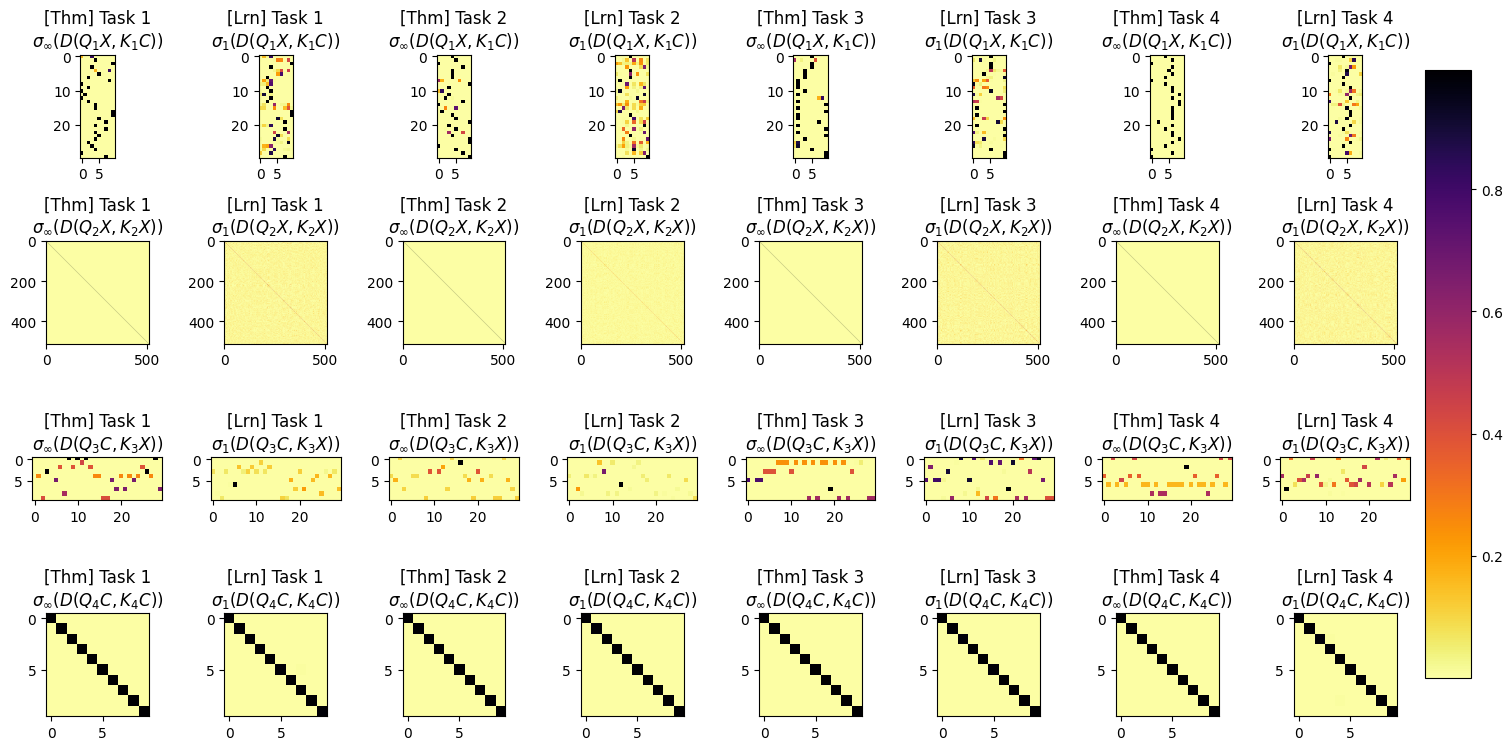

In [7]:
# Setup figure
mult = 1.9
fig, axs = plt.subplots(nrows, 2*ncols, figsize=(2*ncols*mult, nrows*mult))
CMAP = 'inferno_r'
NSAMPLES = 30
N = SXX.shape[1]
SAMPLES = np.random.permutation(N)[:NSAMPLES]
print(f"Visualizing {NSAMPLES} samples out of {N}")

# Create handcrafted model
model_theory = KModel(
    demb, cli_args['dqkv']*demb,
    inv_temp=1000,
    dropout_p=cli_args['dropout'],
    act=cli_args['attn_act'],
)
model_theory = handcrafted_model(model_theory, demb, NDIMS)
model_theory.eval()

# Plot handcrafted attention maps
print("Plotting handcrafted attention maps (Theorem 2.1)...")
im = plot_attn_maps(model_theory, SXX, SCC, axs[:, 2*np.arange(ncols)], 'Thm', SAMPLES, ncols, CMAP)

# Load trained model
model_learned = KModel(
    demb, cli_args['dqkv']*demb,
    inv_temp=cli_args['attn_itemp'],
    dropout_p=cli_args['dropout'],
    act=cli_args['attn_act'],
)
model_learned.load_state_dict(checkpoint['model_state_dict'])
model_learned.eval()

# Plot learned attention maps
print("Plotting learned attention maps...")
im = plot_attn_maps(model_learned, SXX, SCC, axs[:, 2*np.arange(ncols)+1], 'Lrn', SAMPLES, ncols, CMAP)

# Add colorbar
fig.tight_layout()
fig.subplots_adjust(right=0.94)
cbar_ax = fig.add_axes([0.95, 0.1, 0.03, 0.8])
fig.colorbar(im, cax=cbar_ax)

plt.show()

In [8]:
# Save figure
ODIR = 'results'
assert os.path.isdir(ODIR)
OFILE = os.path.join(ODIR, f'attn_d{NDIMS}_k{K}.pdf')
fig.savefig(OFILE, bbox_inches='tight')
print(f"Saved to {OFILE}")

Saved to results/attn_d32_k10.pdf
